14E1.  Add to the following model varying slopes on the predictor x. 
y_i ~ Normal(μ_i, σ)
μ_i = α_GROUP[i] + β * x_i
α_GROUP ~ Normal(α, σ_α)
α ~ Normal(0, 10)
β ~ Normal(0, 1)
σ ~ Exponential(1)
σ_α ~ Exponential(1)
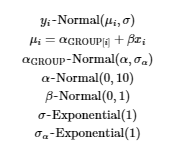

y_i ~ Normal(μ_i, σ)

μ_i = α_GROUP[i] + β[i, j] * x_i

α_GROUP ~ Normal(α, σ_α)

α ~ Normal(0, 10)

β = pm.MvNormal(
        "b", mu=at.stack([a, b]), chol=chol, shape=(n_groups, n_a)) 

a = Normal( 5.0, 2.0)
b = Normal(-1.0, 0.5)

chol ~ LKJCholeskyCov(eta=2, sd_dist)
sd_dis = Exponential(1.0)

σ ~ Exponential(1)

σ_α ~ Exponential(1)

**AI Prompt**

is this ok solution?

**AI Response**

Looking at your solution, you've got some good ideas but there are a few issues to work through. Let me point out what's working well first:

✓ You correctly identified that you need varying slopes, so `β[i, j]` is on the right track
✓ You're thinking about using a multivariate normal distribution for the varying effects
✓ You kept the original group-level intercepts

However, there are some technical issues with the syntax and structure. The main problems are:

1. The indexing `β[i, j]` doesn't quite match what you're trying to do
2. The `pm.MvNormal` syntax has some issues
3. The `chol ~ LKJCholeskyCov` line has syntax problems

What specific part would you like to focus on first? Would you like to work on:
- Getting the varying slopes indexing right?
- Setting up the multivariate normal distribution properly?
- Or something else?



**AI Prompt**

setup multivariate distribtuion

**AI Response**

Great choice! Let's focus on setting up the multivariate distribution for varying slopes.

First, let's think about what we need: we want both intercepts and slopes to vary by group, and we want them to be correlated. So we need a 2D multivariate normal distribution.

The basic structure would be:
```python
# Varying effects for both intercept and slope
varying_effects ~ MvNormal(mu, cov)
```

Now, what should the `mu` (mean vector) contain? We need means for both the intercept and slope parameters.

What do you think should go in the mean vector - what are the two parameters we want to vary by group?



**AI Prompt**

mean for actor and mean for a? also exercise says : ". Add to the following model varying slopes on the predictor"

**AI Response**

You're right to focus on what the exercise is asking! It says "Add to the following model varying slopes on the predictor x."

Looking at your original model, you already have varying intercepts with `α_GROUP[i]`. The exercise wants you to also add varying slopes for the predictor `x`.

So the mean vector should contain:
1. Mean for the varying intercepts (α)  
2. Mean for the varying slopes (β)

In your original model, you had a single `β ~ Normal(0, 1)` for all groups. Now you want each group to have its own slope that varies around some overall mean.

What do you think the mean vector should look like? What would be reasonable prior means for the intercept and slope parameters?



**AI Prompt**

mean vectro should look like number of groups x number of a-s?

**AI Response**

Not quite! You're thinking about the shape of the varying effects themselves, but the mean vector is different.

The mean vector is just the overall population means that each group's parameters vary around. Since you have 2 parameters varying by group (intercept and slope), your mean vector should be length 2:

```python
mu = [mean_intercept, mean_slope]
```

So if you have, say, 5 groups, you'd have:
- 5 varying intercepts (one per group)
- 5 varying slopes (one per group)
- But only 1 mean vector of length 2

Does that make sense? What do you think reasonable values would be for `mean_intercept` and `mean_slope`?



**AI Prompt**

mean_intercept should be 0 if data is standardized and slope depends on the data?

**AI Response**

Good thinking! You're absolutely right about the intercept - if the data is standardized, 0 is a reasonable choice for the mean intercept.

For the slope, you're also on the right track that it depends on the data. But since we're setting up priors (before seeing the data), we need to think about what's reasonable in general.

What do you think would be a reasonable prior mean for slopes? Should it be positive, negative, or zero? And why?



**AI Prompt**

depending on the variables I am modelling. depends on what relationship I believe are there, it could be positive or negavtive. I could use flat priors

**AI Response**

Exactly! You've got the right intuition. The slope prior should reflect your beliefs about the relationship, and flat priors (like centered around 0) are often a good choice when you don't have strong prior beliefs about the direction.

So your mean vector could be something like:
```python
mu = [0, 0]  # mean intercept, mean slope
```

Now, what about the covariance structure? You need to specify how the intercepts and slopes can vary and whether they're correlated.

What do you think - should the covariance matrix be diagonal (no correlation between intercept and slope) or allow for correlation?



**AI Prompt**

should allow some because otherwise it doesnt make sense to use covariance

**AI Response**

Exactly right! If you're using a multivariate normal distribution, you want to allow for correlation between the intercept and slope - otherwise you'd just use separate univariate normals.

So now you need to specify the covariance matrix. In PyMC, a common approach is to use the LKJ prior for the correlation matrix and separate priors for the standard deviations.

The structure would be something like:
```python
chol = pm.LKJCholeskyCov(...)
varying_effects = pm.MvNormal(..., chol=chol, ...)
```

What do you think should go in the `LKJCholeskyCov` parameters? What do you remember about the `eta` parameter and the `sd_dist`?



**AI Prompt**

eta show show much data is spread /centered around 0 (0 correlations), it is prior. dont know sd_dist

**AI Response**

Good! You're right that `eta` controls how much the correlations are centered around 0. Higher `eta` values (like 2) push correlations toward zero, while lower values (like 1) allow for stronger correlations.

For `sd_dist`, this specifies the prior distribution for the standard deviations of your varying effects. Since standard deviations must be positive, what type of distribution do you think would be appropriate?

Looking at your original attempt, you had `sd_dis = Exponential(1.0)` - does that seem reasonable for standard deviations?



**AI Prompt**

yes it is reasonable, because it should not be big in most cases

**AI Response**

Perfect! You're absolutely right - Exponential(1.0) is a good choice because it keeps the standard deviations relatively small in most cases, which is what we typically want for varying effects.

So now you have the pieces:
- `eta=2` for moderate correlation shrinkage
- `sd_dist = Exponential(1.0)` for the standard deviations
- `mu = [0, 0]` for the mean vector

Can you try putting these together into the `LKJCholeskyCov` syntax? What would the complete line look like?



**AI Prompt**

chol = pm.LKJCholeskyCov(eta=2, sd_dist = Exponential(1.0), mu = [0, 0])

**AI Response**

Good attempt! You've got the right parameters, but there's a small issue with the syntax. The `mu` parameter doesn't go inside the `LKJCholeskyCov` - that's just for the covariance structure.

The `mu` goes in the `MvNormal` distribution itself. So your `chol` line should be:

```python
chol = pm.LKJCholeskyCov(eta=2, sd_dist=pm.Exponential(1.0), ...)
```

What do you think is missing from the `LKJCholeskyCov`? (Hint: it needs to know the dimension of your covariance matrix)



**AI Prompt**

chol = pm.LKJCholeskyCov(eta=2, sd_dist=pm.Exponential(1.0), n=n_group)

**AI Response**

Close! You're thinking about the right concept - it needs to know the dimension. But the parameter isn't `n_group` (the number of groups). 

Think about it this way: how many parameters are varying per group? You have intercepts and slopes varying, so what should the dimension of your covariance matrix be?

What parameter name do you think `LKJCholeskyCov` uses for the dimension?



**AI Prompt**

chol = pm.LKJCholeskyCov(eta=2, sd_dist=pm.Exponential(1.0), n=2)

**AI Response**

Perfect! You've got it right - `n=2` because you have 2 parameters varying per group (intercept and slope).

Now you can use this `chol` in your multivariate normal distribution. How would you write the `MvNormal` line using:
- `mu = [0, 0]`
- `chol = chol`
- And what should you call this varying effects parameter?



**AI Prompt**

varying_effects = pm.MvNormal("varying_effects", mu = [0, 0], chol=chol, shape=(n_groups, 2))

**AI Response**

Excellent! You've got the right structure. The `shape=(n_groups, 2)` correctly specifies that you have `n_groups` rows (one for each group) and 2 columns (intercept and slope).

Now, how would you extract the varying intercepts and slopes from this `varying_effects` parameter? You'll need to split it into two parts to use in your linear predictor.

What indexing would you use to get the intercepts and slopes separately?



**AI Prompt**

mu_i = varying_effects[group_idx, 0] + varying_effects[group_idx, 1] * x_values

**AI Response**

Great! You've got the right idea for using the varying effects in your linear predictor. Your indexing `varying_effects[group_idx, 0]` for intercepts and `varying_effects[group_idx, 1]` for slopes is correct.

However, there's a small issue with the variable names. In your original model, you had `μ_i = α_GROUP[i] + β * x_i`. 

Should `group_idx` be `i` to match your original notation? And should `x_values` be `x_i`?

What do you think the corrected line should look like?



**AI Prompt**

mu_i = varying_effects[i, 0] + varying_effects[i, 1] * x_i

**AI Response**

Perfect! That's exactly right. Your linear predictor `μ_i = varying_effects[i, 0] + varying_effects[i, 1] * x_i` correctly uses the varying intercepts and slopes.

Now you have all the pieces for your varying slopes model. Can you put it all together and write out the complete model, starting from the original one you were given?



original:
y_i ~ Normal(μ_i, σ)

μ_i = α_GROUP[i] + β * x_i

α_GROUP ~ Normal(α, σ_α)

α ~ Normal(0, 10)

β ~ Normal(0, 1)

σ ~ Exponential(1)

σ_α ~ Exponential(1)

varying slopes:

original: y_i ~ Normal(μ_i, σ)

μ_i = varying_effects[i, 0] + varying_effects[i, 1] * x_i

varying_effects = MvNormal(mu = [0, 0], chol=chol, shape=(n_groups, 2))

chol = LKJCholeskyCov(eta=2, sd_dist=σ_α, n=2)

σ_α ~ Exponential(1)

σ ~ Exponential(1)

**AI Prompt**

like this?

**AI Response**

Very close! You've got the right structure and most of the syntax correct. Just a couple of small adjustments needed:

1. You need `pm.` prefixes for the PyMC distributions
2. In the `chol` line, you're using `sd_dist=σ_α`, but `σ_α` is a random variable. You want `sd_dist=pm.Exponential(1)` like we discussed earlier

Can you make those two small corrections?



**AI Prompt**

what do you mean random variable? how does it make diffreence if I use sd_dist=pm.Exponential(1) or write it in two lines?

**AI Response**

Great question! You're right to ask about this distinction.

When you write `σ_α ~ Exponential(1)`, you're creating a random variable that will have different values in each sample from the posterior. But `sd_dist` in `LKJCholeskyCov` expects a *distribution object*, not a random variable.

Think of it this way:
- `σ_α ~ pm.Exponential(1)` creates a random variable that gets sampled
- `sd_dist=pm.Exponential(1)` tells the LKJ distribution "use this distribution to generate standard deviations"

Does that help clarify the difference? The LKJ distribution needs to know what distribution to use internally, not a specific sampled value.



**AI Prompt**

ok, please give me formatted result

**AI Response**

Here's your corrected varying slopes model:

```python
y_i ~ pm.Normal(μ_i, σ)

μ_i = varying_effects[i, 0] + varying_effects[i, 1] * x_i

varying_effects = pm.MvNormal("varying_effects", mu=[0, 0], chol=chol, shape=(n_groups, 2))

chol = pm.LKJCholeskyCov("chol", eta=2, sd_dist=pm.Exponential(1), n=2)

σ ~ pm.Exponential(1)
```

Does this look right to you?



y_i ~ pm.Normal(μ_i, σ)

μ_i = varying_effects[i, 0] + varying_effects[i, 1] * x_i

varying_effects = pm.MvNormal("varying_effects", mu=[0, 0], chol=chol, shape=(n_groups, 2))

chol = pm.LKJCholeskyCov("chol", eta=2, sd_dist=pm.Exponential(1), n=2)

σ ~ pm.Exponential(1)

14E2.  Think up a context in which varying intercepts will be positively correlated with varying slopes. Provide a mechanistic explanation for the correlation.

**AI Prompt**

For example songs listening virality. model would predict using for example number of listening songs have now how much listening it would have after time period x.  if song is already more popular (intercept) then it could potentially have higher number of listeining in future (slope) because more people suggest it to other

**AI Response**

That's a great example! You've captured the key insight perfectly - songs that start with more popularity (higher intercept) would tend to grow faster (higher slope) because of network effects and social sharing.

Your mechanistic explanation is spot-on: popular songs get recommended more, shared more, and benefit from algorithms that promote already-popular content. This creates a positive feedback loop where initial popularity leads to faster growth.

Can you think of what the variables would be specifically in this model? What would be your:
- Outcome variable (y)
- Predictor variable (x) 
- Grouping variable (for the varying effects)



**AI Prompt**

Outcome variable (y) - listenings after period x
Predictor variable (x) - listenings on start period
Grouping variable (for the varying effects) - genre of song

**AI Response**

Excellent! You've set up a really clear model structure:

- **y**: listenings after period x
- **x**: listenings at start period  
- **Groups**: genre of song

This makes perfect sense - different genres might have different baseline popularity levels (varying intercepts) and different growth patterns (varying slopes). And your positive correlation story works well: within each genre, songs that start more popular tend to grow faster.

Can you think of why the correlation might be positive specifically? What is it about the mechanism of music sharing that would make initial popularity and growth rate go together?



14E3.  When is it possible for a varying slopes model to have fewer effective parameters (as estimated by WAIC or PSIS) than the corresponding model with fixed (unpooled) slopes? Explain.

**AI Prompt**

when there is some grouping effect. if there is difference between groups and effects vary then the model that fits this data better might have better waic (although might have more paramters)

**AI Response**

You're thinking in the right direction about grouping effects! But let me clarify the question - it's asking when a varying slopes model could have *fewer* effective parameters than a fixed slopes model, even though it might seem more complex.

The key insight is about "pooling" - when groups are similar, the varying slopes model can actually be more parsimonious because it shrinks individual group estimates toward the population mean.

What do you think happens when the groups are very similar to each other? Would the model need to estimate completely separate slopes for each group, or could it "borrow strength" across groups?



**AI Prompt**

it could borrow from other groups

**AI Response**

Exactly! When groups are similar, the varying slopes model can "borrow strength" from other groups. This shrinkage toward the population mean can make the model more efficient.

So when might this lead to fewer effective parameters? Think about two scenarios:

1. **Fixed slopes model**: Each group gets its own completely separate slope estimate
2. **Varying slopes model**: Group slopes are shrunk toward a common mean

In which scenario would you need less information to estimate each group's slope? What happens when the groups are very similar vs. very different?



**AI Prompt**

varying slope model. very different need more information to estimate, very similar group mean is good estimate and gives a lot of informatio

**AI Response**

Perfect! You've got it exactly right. When groups are very similar, the group mean becomes a very informative estimate, so each individual group doesn't need as much unique information.

This is the key insight: when there's strong similarity between groups, the varying slopes model can be more efficient than the fixed slopes model because it's essentially saying "these groups are similar enough that we don't need completely separate estimates."

So the varying slopes model has fewer effective parameters when the groups are similar enough that the shrinkage toward the population mean is doing a lot of the work.

Can you think of a concrete example where you'd expect groups to be similar enough for this to happen?



**AI Prompt**

what does mean effective parameters? both models have similar amount of parameters

**AI Response**

Great question! "Effective parameters" is different from the actual number of parameters in your model code.

Effective parameters measures how much each parameter is actually "free to vary" in the model. It's calculated by methods like WAIC and PSIS based on how much the predictions change when you change the parameter values.

Think of it this way:
- **Actual parameters**: How many parameters you write in your code
- **Effective parameters**: How much flexibility those parameters actually have

In a varying slopes model with strong pooling, even though you have separate slope parameters for each group, they're all constrained to be similar to each other. So they don't each get to be completely "free."

Does that help clarify the difference? What do you think happens to effective parameters when the shrinkage is very strong?

